# Phase 1 — Test final FD001 (ouverture unique)

**Ce notebook ouvre `test_FD001.txt` / `RUL_FD001.txt` pour la première et unique fois.** Le
résultat obtenu ici est rapporté tel quel dans le mémoire, sans retouche des hyperparamètres
ou du pipeline après coup — c'est ce qui garantit que le score reflète la généralisation réelle,
et pas un ajustement indirect sur le test.

**Modèles évalués** : régression linéaire et forêt aléatoire (ré-entraînées à l'identique,
entièrement déterministes), et le LSTM (poids chargés depuis
`models/lstm_fd001_seed42.pt`, entraîné dans `05_lstm_fd001.ipynb`). Toutes les statistiques
de sélection de capteurs et de normalisation viennent du train uniquement, jamais du test.

**Plafonnement du RUL de test** : `RUL_FD001.txt` donne le RUL réel, non plafonné. On le
plafonne à 125 avant de calculer les scores, pour rester cohérent avec ce que les modèles ont
appris à prédire (cf. Heimes 2008 et la pratique standard sur C-MAPSS).

Critère « fait » (plan d'exécution, Phase 1) : scores test rapportés.

In [ ]:
import sys
sys.path.append("..")

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

from src.metrics import asymmetric_score, rmse
from src.preprocessing import (
    add_piecewise_rul,
    aggregate_window_features,
    compute_norm_stats,
    make_windows,
    normalize,
    select_features,
    split_by_unit,
)
from src.torch_model import RULRegressor

SEED = 42
WINDOW_SIZE = 30
RUL_CAP = 125

DATA_DIR = "../DATA/CMaps"
INDEX_NAMES = ["unit_number", "time_cycles"]
SETTING_NAMES = ["setting_1", "setting_2", "setting_3"]
SENSOR_NAMES = [f"sensor_{i}" for i in range(1, 22)]
COL_NAMES = INDEX_NAMES + SETTING_NAMES + SENSOR_NAMES

train_full = pd.read_csv(f"{DATA_DIR}/train_FD001.txt", sep=r"\s+", header=None)
train_full = train_full.iloc[:, : len(COL_NAMES)]
train_full.columns = COL_NAMES

# Même split que 04_baseline_fd001.ipynb / 05_lstm_fd001.ipynb : reconstruit uniquement pour
# retrouver les mêmes capteurs sélectionnés et les mêmes stats de normalisation (calculées sur
# train_raw seul). Le val n'est pas réutilisé ici, seul le test compte pour cette évaluation.
train_raw, _ = split_by_unit(train_full, val_fraction=0.2, seed=SEED)
selected_sensors = select_features(train_raw, SENSOR_NAMES, std_threshold=1e-2)
norm_stats = compute_norm_stats(train_raw, selected_sensors)

train_norm = normalize(train_raw, selected_sensors, norm_stats)
train_rul = add_piecewise_rul(train_norm, cap=RUL_CAP)
X_train_win, y_train, _ = make_windows(train_rul, selected_sensors, window_size=WINDOW_SIZE, target_col="RUL")
X_train_agg = aggregate_window_features(X_train_win)

linreg = LinearRegression().fit(X_train_agg, y_train)
rf = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1).fit(X_train_agg, y_train)

lstm = RULRegressor(n_features=len(selected_sensors), hidden_size=64)
lstm.load_state_dict(torch.load("../models/lstm_fd001_seed42.pt", map_location="cpu"))
lstm.eval()

len(selected_sensors)

14

In [ ]:
test_raw = pd.read_csv(f"{DATA_DIR}/test_FD001.txt", sep=r"\s+", header=None)
test_raw = test_raw.iloc[:, : len(COL_NAMES)]
test_raw.columns = COL_NAMES

test_norm = normalize(test_raw, selected_sensors, norm_stats)  # stats du train, jamais recalculées sur le test

# En test, on ne prédit qu'au DERNIER cycle observé de chaque moteur (last_only=True) : c'est
# la seule position où le vrai RUL (fourni séparément) est défini.
X_test_win, _, units_test = make_windows(test_norm, selected_sensors, window_size=WINDOW_SIZE, last_only=True)

rul_true = pd.read_csv(f"{DATA_DIR}/RUL_FD001.txt", sep=r"\s+", header=None, names=["RUL"])
rul_true.index = rul_true.index + 1  # unit_number est numéroté à partir de 1, comme les lignes du fichier

y_test_true = rul_true.loc[units_test, "RUL"].clip(upper=RUL_CAP).to_numpy()

X_test_win.shape, y_test_true.shape

((100, 30, 14), (100,))

In [ ]:
X_test_agg = aggregate_window_features(X_test_win)

with torch.no_grad():
    lstm_pred = lstm(torch.tensor(X_test_win, dtype=torch.float32)).numpy()

predictions = {
    "Régression linéaire": linreg.predict(X_test_agg),
    "Forêt aléatoire": rf.predict(X_test_agg),
    "LSTM": lstm_pred,
}

test_results = pd.DataFrame([
    {"modèle": name, "RMSE_test": rmse(y_test_true, y_pred), "score_asymétrique_test": asymmetric_score(y_test_true, y_pred)}
    for name, y_pred in predictions.items()
])

# Scores val obtenus dans 04_baseline_fd001.ipynb / 05_lstm_fd001.ipynb, pour comparer
# généralisation val -> test (pas recalculés ici, juste recopiés pour le tableau).
val_scores = {"Régression linéaire": 21.536573, "Forêt aléatoire": 17.899715, "LSTM": 13.088298}
test_results["RMSE_val"] = test_results["modèle"].map(val_scores)

test_results[["modèle", "RMSE_val", "RMSE_test", "score_asymétrique_test"]]

,modèle,RMSE_val,RMSE_test,score_asymétrique_test
0,Régression linéaire,21.536573,17.767336,561.061795
1,Forêt aléatoire,17.899715,17.869847,912.302461
2,LSTM,13.088298,12.225107,242.402475


**Ce que montre ce tableau** : `RMSE_val` est le score déjà obtenu sur la validation (moteurs
tenus à l'écart de l'entraînement, mais toujours issus de `train_FD001.txt`) ; `RMSE_test` et
`score_asymétrique_test` sont les scores sur le vrai test, jamais vu jusqu'ici. Si `RMSE_test`
reste proche de `RMSE_val` pour un modèle, ça confirme que le val donnait une estimation fiable
de sa généralisation. Un écart important (test nettement pire que val) indiquerait que le
split val/train ne représentait pas bien la difficulté du vrai test.

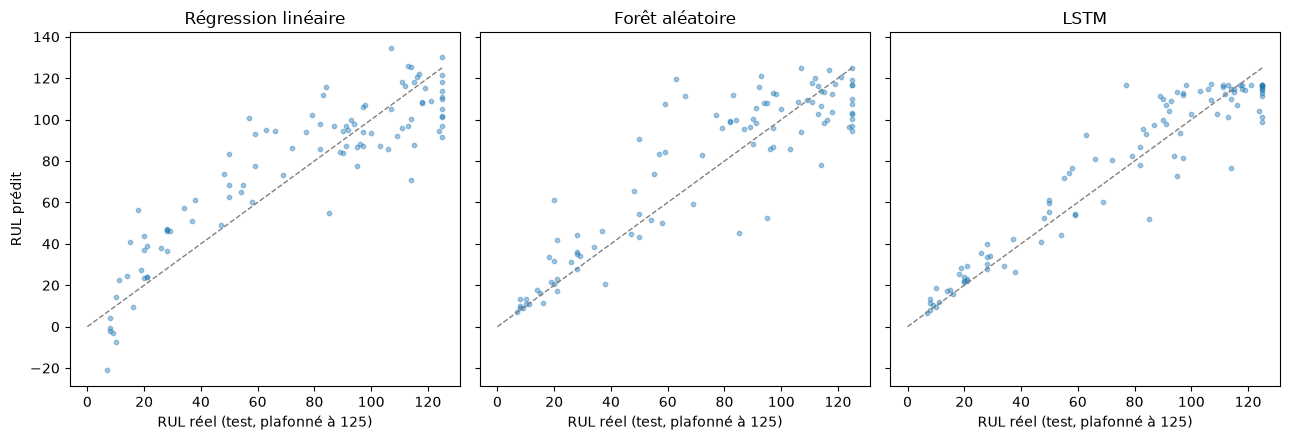

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharex=True, sharey=True)

for ax, (name, y_pred) in zip(axes, predictions.items()):
    ax.scatter(y_test_true, y_pred, s=10, alpha=0.4)
    ax.plot([0, RUL_CAP], [0, RUL_CAP], color="grey", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("RUL réel (test, plafonné à 125)")

axes[0].set_ylabel("RUL prédit")
fig.tight_layout()

**Ce que montre cette figure** : chaque point est un moteur du test (un seul point par
moteur, contrairement aux figures de validation qui avaient plusieurs fenêtres par moteur).
Avec seulement 100 moteurs, le nuage est plus clairsemé qu'en validation, mais la lecture est
la même : proximité à la diagonale = bonne prédiction. C'est la comparaison la plus directe et
la plus honnête entre les trois modèles, puisqu'aucun n'a jamais vu ces données avant cette
exécution.